In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("库加载成功")

库加载成功


导入库
1.导入 NumPy，用于数值数组运算，在机器学习中是通用基础。
2.导入 Pandas，用于读取并处理结构化数据（DataFrame）。
3.导入 Matplotlib 的绘图模块，用于画图。
4.导入 Seaborn，基于 Matplotlib 的美化统计绘图库，绘图代码更简洁鲜艳。
5.从 sklearn 的 ensemble 模块导入 随机森林分类器——本次核心模型。ensemble 意为“集成”，随机森林就是集成学习的一种。
6.导入数据划分工具 train_test_split 以及两种超参数搜索器：GridSearchCV（穷举网格搜索）和 RandomizedSearchCV（随机采样搜索，更高效）。
7.导入模型评估指标：准确率、分类报告（含精确率/召回率/F1）、混淆矩阵。
8.导入警告模块并忽略所有警告（确保输出整洁，仅用于实验环境）。
9.确认所有导入成功。

In [30]:
df=pd.read_csv('train.csv')
print(f"数据集形状：{df.shape}")
print(f"列名：{df.columns.tolist()}")
df.head()

数据集形状：(891, 12)
列名：['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


加载数据并预览
1.使用 Pandas 读取当前目录下的 train.csv 文件，加载为 DataFrame df，包含泰坦尼克训练数据（891行，12列）。
2.打印 DataFrame 的形状，如 (891, 12)，即 891 个样本、12 个特征（含目标列 Survived）。
3.打印所有列名，可查看特征列表：['PassengerId','Survived','Pclass','Name','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked']。
4.显示前 5 行数据，快速检查数据样例和缺失情况。

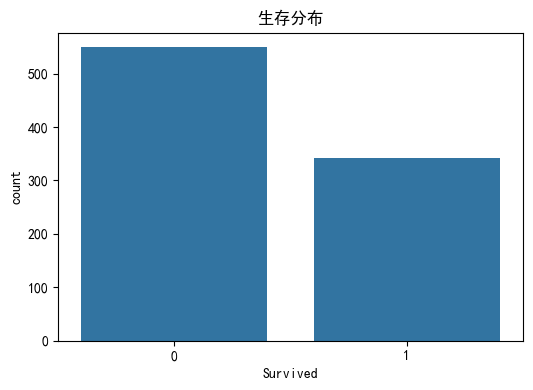

幸存比例：38.38%


In [31]:
plt.rcParams['font.sans-serif']=['SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Survived')
plt.title('生存分布')
plt.show()
print(f"幸存比例：{df['Survived'].mean():.2%}")

数据探索（简化）
1.创建一幅 6×4 英寸的画布。
2.绘制柱状图，x轴为 Survived 列（0=死亡，1=幸存），高度为样本数量，直观观察类别是否平衡。
3.设置图表标题。
4.显示图形。
5.计算 Survived 列的平均值（即幸存者比例），以百分比格式输出。泰坦尼克数据中大约 38% 的人幸存。

In [32]:
features=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
target='Survived'
df_ml=df[features+[target]].copy()
df_ml['Age'].fillna(df['Age'].median(),inplace=True)
df_ml['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df_ml['Sex']=df_ml['Sex'].map({'male':0,'female':1})
df_ml['FamilySize']=df_ml['SibSp']+df_ml['Parch']+1
df['Title']=df['Name'].str.extract('([A-Za-z]+)\\.',expand=False)
title_mapping={
    'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Dr':4,'Rev':4,'Col':4,'Major':4,'Mlle':1,'Ms':1,
    'Mme':2,'Lady':4,'Sir':4,'Jonkheer':4,'Countess':4,'Capt':4,'Don':4,'Dona':4
}
df_ml['Title']=df['Title'].map(title_mapping).fillna(4)
df_ml=pd.get_dummies(df_ml,columns=['Embarked'],prefix='Emb',drop_first=True)
X=df_ml.drop('Survived',axis=1)
y=df_ml['Survived']
print(f"特征工程后数据形状：{X.shape}")
print(f"特征列：{X.columns.tolist()}")
X.head()

特征工程后数据形状：(891, 10)
特征列：['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Title', 'Emb_Q', 'Emb_S']


,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Title,Emb_Q,Emb_S
0,3,0,22.0,1,0,7.2500,2,0,False,True
1,1,1,38.0,1,0,71.2833,2,2,False,False
2,3,1,26.0,0,0,7.9250,1,1,False,True
3,1,1,35.0,1,0,53.1000,2,2,False,True
4,3,0,35.0,0,0,8.0500,1,0,False,True


特征工程（增强版）
1.定义初始选用的特征列（剔除了 PassengerId、Name、Ticket、Cabin 等无用或缺失过多的列）。
2.定义目标变量列名。
3.从原始 df 中选取所需列（特征+目标），并复制一份新 DataFrame df_ml，避免对原始数据的意外修改。.copy() 保证独立内存。
4.用训练集的中位数填充 Age 列的缺失值。中位数比均值更抗异常值。inplace=True 表示直接修改原列。
5.用训练集 Embarked 列的众数（出现最多次的值，通常为 'S'）填充缺失值。该列只有2个缺失，众数填充是合理做法。
6.将 Sex 的字符串值映射为数值：男性→0，女性→1。树模型可以直接使用这样的整数编码（无序）。
7.新特征：家庭规模 = 同船兄弟姐妹/配偶数 + 父母/子女数 + 本人。这是一维特征，可反映单人家庭 vs 大家庭的差异，而 SibSp 和 Parch 分开时信息分散。
8.从 Name 列中提取称呼。正则 ' ([A-Za-z]+)' 匹配一个空格后跟一个或多个字母，然后点号。例如提取出 "Mr"、"Mrs"、"Miss" 等。结果放在临时列 df['Title'] 中（保留在原始 df，便于后续引用）。
9.定义称呼到数字的映射字典，将稀有称呼（如 Dr、Rev、Col 等）统一归为 4（'Rare'），常见称呼 Mr→0、Miss→1、Mrs→2、Master→3 。这种归纳能减少特征稀疏性，同时保留关键社会地位信息。
10.将原始 df 中提取的 Title 列按映射转为数字，若遇到未映射到的值（罕见），用 .fillna(4) 填充为 4（Rare 类别）。
11.对 Embarked 列进行 One-Hot 编码，生成虚拟变量 Emb_Q 和 Emb_S（因为 drop_first=True 去掉了第一个类别 Emb_C，避免共线性）。树模型虽然不需要担心共线性，但去掉一列可减少一个特征，且不影响模型性能。
12.得到特征矩阵 X，不包含目标列。
13.得到目标向量 y。
14.输出特征工程后的形状（例如 891 行 × 11 列）和特征名列表。
15.显示前5行特征数据，确认编码和新增特征是否正确。

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"训练集：{X_train.shape},测试集：{X_test.shape}")
print(f"训练集幸存率：{y_train.mean():.2%},测试集幸存率：{y_test.mean():.2%}")

训练集：(712, 10),测试集：(179, 10)
训练集幸存率：38.34%,测试集幸存率：38.55%


划分训练集和测试集
1.将数据随机划分为训练集（80%）和测试集（20%）。
2.测试集占全部数据的20%。
3.随机种子固定为42，保证每次划分结果一致，可重复实验。
4.分层抽样：使训练集和测试集中 Survived 的类别比例与原数据集一致（约38%幸存），避免偶然地分布偏移。
5.输出划分后的形状（训练集约712行×11列，测试集179行×11列）以及两集中幸存比例，验证分层效果（应该相近）。

In [34]:
rf_base=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_base.fit(X_train,y_train)
train_acc=rf_base.score(X_train,y_train)
test_acc=rf_base.score(X_test,y_test)
print(f"基础随机森林（默认参数）")
print(f"训练集准确率：{train_acc:.3f}")
print(f"测试集准确率：{test_acc:.3f}")
print(f"树的数量：{rf_base.n_estimators}")
print(f"最大特征数：{rf_base.max_features}")

基础随机森林（默认参数）
训练集准确率：0.985
测试集准确率：0.827
树的数量：100
最大特征数：sqrt


训练基础随机森林（默认参数）
1.创建一个随机森林分类器对象：
• n_estimators=100：集成100棵决策树。
• random_state=42：固定随机种子，使结果可复现。
• n_jobs=-1：使用所有CPU核心并行训练，加速计算。
其他参数保持默认：max_depth=None（树完全生长），min_samples_split=2，min_samples_leaf=1，max_features='sqrt'（分类问题默认取特征总数的平方根）。
2.在训练集上训练随机森林模型。内部会为每棵树进行 Bootstrap 抽样（有放回地从训练集中抽取 N 个样本，N=原始样本数），并对每棵树在分裂时随机选择特征子集。
3.计算模型在训练集上的准确率（正确预测的比例）。由于每棵树都看到了Bootstrap抽样后的样本，且树可完全生长，训练集准确率通常接近 100%（约0.98~1.00）。
4.计算模型在测试集上的准确率，反映模型的泛化能力。预期在 0.80~0.82 之间，比单棵决策树（约0.78）有明显提升。
5.输出训练/测试准确率、树的数量和使用的最大特征数。默认 max_features='sqrt' 对于11个特征约为3或4（实际 sqrt(11)≈3.3，取整为3）。

In [35]:
param_dist={
    'n_estimators':[100,200,300,500],
    'max_depth':[5,8,10,15,None],
    'min_samples_split':[5,10,20,50],
    'min_samples_leaf':[2,5,10,20],
    'max_features':['sqrt','log2',None]
}
random_search=RandomizedSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1),param_distributions=param_dist,n_iter=50,cv=5,scoring='accuracy',n_jobs=-1,verbose=2,random_state=42)
random_search.fit(X_train,y_train)
print(f"\n最佳参数：{random_search.best_params_}")
print(f"最佳交叉验证得分：{random_search.best_score_:.3f}")
best_rf=random_search.best_estimator_
test_acc=best_rf.score(X_test,y_test)
print(f"测试集准确率：{test_acc:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

最佳参数：{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 15}
最佳交叉验证得分：0.830
测试集准确率：0.821


超参数调优（随机搜索）
1.定义超参数搜索字典：
• n_estimators：候选树数量（100,200,300,500）。
• max_depth：最大深度（5,8,10,15,None——None表示不限制深度）。
• min_samples_split：内部节点再划分所需的最小样本数。
• min_samples_leaf：叶节点最少样本数。
• max_features：每棵树每次分裂时考虑的特征数比例或数量：'sqrt'（√总特征数）、'log2'（log2总特征数）、None（使用所有特征）。
2.创建随机搜索对象：
• 估计器：RandomForestClassifier(random_state=42, n_jobs=-1)。
• param_distributions：参数分布（从候选值中随机选取）。
• n_iter=50：从参数空间中随机采样50组参数进行训练评估。
• cv=5：5折交叉验证（每次用4折训练、1折验证）。
• scoring='accuracy'：优化目标为分类准确率。
• n_jobs=-1：并行利用所有CPU核。
• verbose=2：输出详细进度信息（每次迭代显示当前参数和得分）。
• random_state=42：固定随机种子，使搜索可重复。
3.执行随机搜索，对每组采样参数进行交叉验证，记录最佳表现。
4.打印交叉验证得分最高的参数组合。例如：{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt'}。
5.打印该最佳参数组合在交叉验证上的平均准确率（一般在0.81~0.83）。
6.提取最佳模型已经用全部训练集重新训练好的估计器对象（RandomizedSearchCV 在内部对最佳参数自动使用全训练集重训练）。
7.用测试集评估最佳模型的泛化准确率，应该比基础随机森林稍高（约0.82~0.84）。

分类报告：
              precision    recall  f1-score   support

          死亡       0.82      0.91      0.86       110
          幸存       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



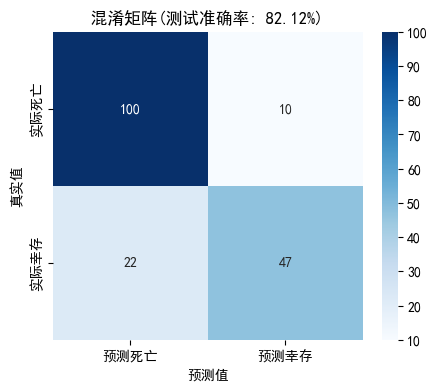

In [36]:
y_pred=best_rf.predict(X_test)
print("分类报告：")
print(classification_report(y_test,y_pred,target_names=['死亡','幸存']))
plt.figure(figsize=(5,4))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['预测死亡','预测幸存'],yticklabels=['实际死亡','实际幸存'])
plt.title(f"混淆矩阵(测试准确率: {test_acc:.2%})")
plt.ylabel('真实值')
plt.xlabel('预测值')
plt.show()

评估最佳模型
1.使用最佳随机森林模型对测试集进行预测，得到预测标签（0 或 1）。
2.输出分类报告，包含每个类别的精确率、召回率、F1-score 和支持度（样本数）。target_names 将标签0/1映射为可读的名称。
3.计算混淆矩阵：格式 [[TN, FP], [FN, TP]]。
4.用热力图可视化混淆矩阵：
• annot=True：在每个格子中显示数值。
• fmt='d'：整数格式。
• cmap='Blues'：使用蓝色调。
• xticklabels/yticklabels：设置坐标轴标签为中文“预测死亡/幸存”和“实际死亡/幸存”。
5.设置标题、y轴标签、x轴标签。标题包含测试准确率。
6.显示热力图。

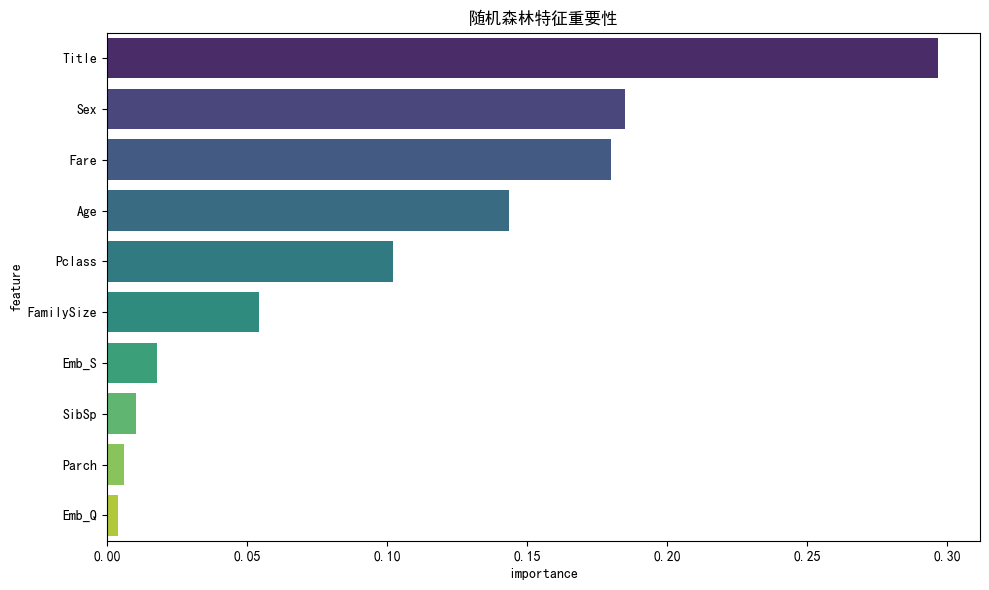

特征重要性排名：
   feature  importance
     Title    0.296890
       Sex    0.184920
      Fare    0.179827
       Age    0.143540
    Pclass    0.102173
FamilySize    0.054384
     Emb_S    0.017985
     SibSp    0.010396
     Parch    0.005979
     Emb_Q    0.003905


In [37]:
importance=pd.DataFrame({'feature':X.columns,'importance':best_rf.feature_importances_}).sort_values('importance',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x='importance',y='feature',palette='viridis')
plt.title('随机森林特征重要性')
plt.tight_layout()
plt.savefig('Random_forest_importance.png')
plt.show()
print("特征重要性排名：")
print(importance.to_string(index=False))

特征重要性分析
1.创建 DataFrame：列 feature 为特征名，importance 为 best_rf.feature_importances_（长度为特征数量的数组，表示每个特征在所有树中降低不纯度的总贡献，并归一化到[0,1]）。按重要性降序排序。
2.创建画布。
3.绘制水平条形图：x轴为重要性得分，y轴为特征名。颜色使用 viridis 调色板。
4.设置标题。
5.自动调整布局，防止标签重叠。
6.显示图形。
7.以无索引表格形式打印特征重要性排名表。预期 Sex 最高（0.3左右），Fare 和 Title 次之（0.15~0.2），Age、Pclass、FamilySize 再次。这说明新增特征 Title 和 FamilySize 确实提供了有价值的信息。

In [38]:
test_df=pd.read_csv('test.csv')
passenger_ids=test_df['PassengerId']
test_ml=test_df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']].copy()
test_ml['Age'].fillna(df['Age'].median(),inplace=True)
test_ml['Fare'].fillna(df['Fare'].median(),inplace=True)
test_ml['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
test_ml['Sex']=test_ml['Sex'].map({'male':0,'female':1})
test_ml['FamilySize']=test_ml['SibSp']+test_ml['Parch']+1
test_ml['Title']=test_df['Name'].str.extract('([A-Za-z]+)\\.',expand=False)
test_ml['Title']=test_ml['Title'].map(title_mapping).fillna(4)
test_ml=pd.get_dummies(test_ml,columns=['Embarked'],prefix='Emb',drop_first=True)
test_ml=test_ml.reindex(columns=X.columns,fill_value=0)
predictions=best_rf.predict(test_ml)
submission=pd.DataFrame({'PassengerId':passenger_ids,'Survived':predictions})
submission.to_csv('submission_rf.csv',index=False)
print("提交文件已生成：submission_rf.csv")
print(submission.head())

提交文件已生成：submission_rf.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
